# Utah Legislature Bill Outcome Analysis
### DS 2500 Final Project — Analysis Methods

This notebook implements the analysis pipeline for predicting Utah bill outcomes (2016–2026) using bill characteristics, sponsor party affiliation, and ACS economic indicators.

**Research Questions:**
1. Which aspects of a bill have the most influence over its outcome?
2. Can the outcome of a bill be predicted by analyzing its characteristics?
3. Do economic indicators influence bill outcomes, and does including them improve predictability?

## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

In [2]:
df_raw = pd.read_csv('df_bills.csv')
print(f"Full dataset: {df_raw.shape[0]} bills")

# Filter to only bills that had a floor sponsor.
# A floor sponsor is a procedural prerequisite for passage — bills without one
# never had a real chance of passing, so including them would let the model
# "cheat" by just learning that gatekeeper step instead of substantive patterns.
df = df_raw[df_raw['floorspon1'] == 1].copy()
print(f"After filtering to floor-sponsored bills: {df.shape[0]} bills ({df.shape[0]/df_raw.shape[0]:.1%} of total)")
print(f"\nOutcome distribution (passed):")
print(df['passed'].value_counts().to_string())
print(f"\nPass rate in analysis sample: {df['passed'].mean():.1%}")
print(f"(vs. {df_raw['passed'].mean():.1%} in full dataset)")
print(f"\nSponsor party distribution:")
print(df['party'].value_counts().to_string())

Full dataset: 8705 bills
After filtering to floor-sponsored bills: 6730 bills (77.3% of total)

Outcome distribution (passed):
passed
1    5347
0    1383

Pass rate in analysis sample: 79.5%
(vs. 61.4% in full dataset)

Sponsor party distribution:
party
Rep    5789
Dem     866
FWD      75


## 1. Exploratory Data Analysis

### 1.1 Define Variable Groups

Based on the data plan, we organize covariates into groups for staged modeling:
- `money1` = binary flag for whether the bill had money appropriated
- `money_sum_real` = inflation-adjusted total appropriation amount
- `cospon1` / `cospon_num` = cosponsor flag and count (available from 2023 onward only)
- `num_sub_new` = derived substitute count from enrolled version (available all years)
- `committee1` = binary flag for coming out of committee
- `party1` = binary flag for Republican sponsor (1 = Rep, 0 = Dem/FWD)
- `floorspon1` is excluded — we've already filtered to bills with a floor sponsor
- `passed` = binary outcome; `location_stage` = ordinal outcome (0–3)

In [3]:
# Subject area dummies (22 groups)
SUBJECT_COLS = [
    'agri_food', 'arts_cult_rec', 'bus_comm', 'civ_rights_libs', 'crim_justice',
    'econ_dev', 'ed_k12', 'elect_gov', 'energy', 'env_nr', 'fam_ss',
    'health_care', 'higher_ed', 'house_land_use', 'labor_ee', 'local_gov',
    'no_subject', 'pub_safe_emerg', 'retire_ben', 'tax_fin', 'tech_data', 'transpo'
]

# Bill-level covariates (floorspon1 excluded — constant after filtering)
BILL_COVARIATES = ['committee1', 'money1', 'num_sub_new', 'money_sum_real', 'party1']

# Cosponsor variables (only available 2023+)
COSPONSOR_VARS = ['cospon1', 'cospon_num']

# ACS economic indicators (missing for 2024-2026)
ECON_VARS = ['real_gdp', 'rental_vacancy_rate', 'poverty_rate', 'inflation']

# Originating chamber — binary encode
df['house_origin'] = (df['originating_chamber'] == 'House').astype(int)

# Subjects changed — binary encode
df['subjects_changed_bin'] = df['subjects_changed'].astype(int)

print("Variable groups defined.")
print(f"  Subject dummies: {len(SUBJECT_COLS)}")
print(f"  Bill covariates: {BILL_COVARIATES}")
print(f"  Cosponsor vars (2023+ only): {COSPONSOR_VARS}")
print(f"  ACS economic vars: {ECON_VARS}")

Variable groups defined.
  Subject dummies: 22
  Bill covariates: ['committee1', 'money1', 'num_sub_new', 'money_sum_real', 'party1']
  Cosponsor vars (2023+ only): ['cospon1', 'cospon_num']
  ACS economic vars: ['real_gdp', 'rental_vacancy_rate', 'poverty_rate', 'inflation']


### 1.2 Pass Rates by Subject Area

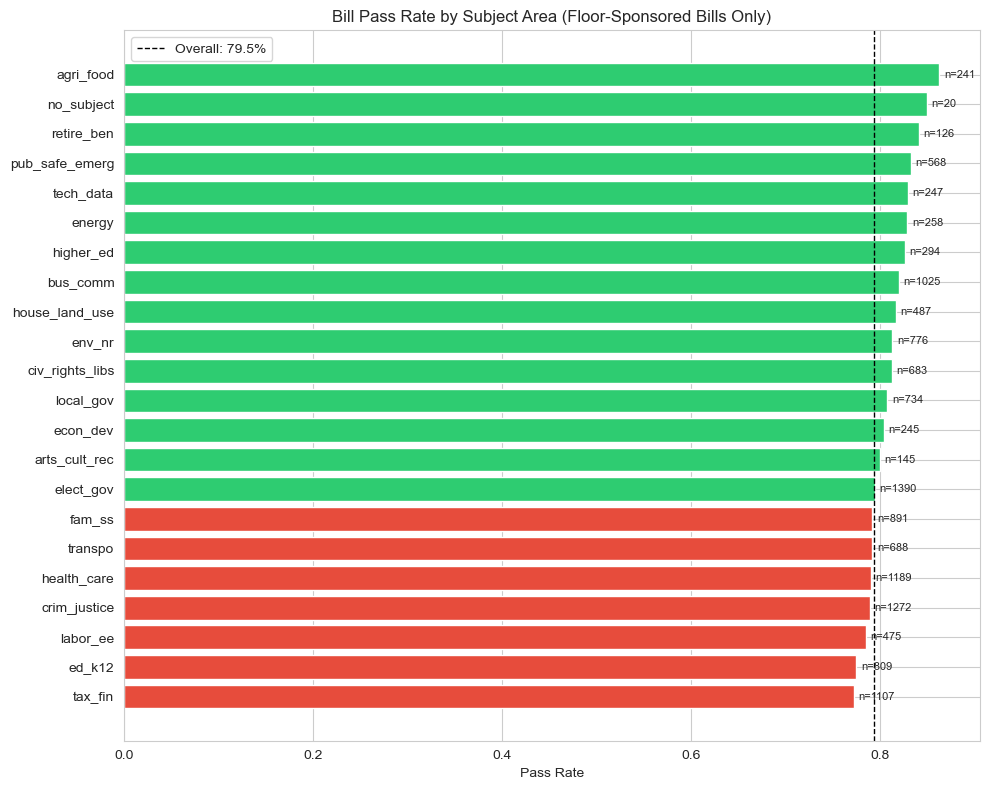

In [4]:
pass_rates = {}
for col in SUBJECT_COLS:
    subset = df[df[col] == 1]
    if len(subset) > 0:
        pass_rates[col] = {'pass_rate': subset['passed'].mean(), 'count': len(subset)}

pr_df = pd.DataFrame(pass_rates).T.sort_values('pass_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if r > df['passed'].mean() else '#e74c3c' for r in pr_df['pass_rate']]
bars = ax.barh(pr_df.index, pr_df['pass_rate'], color=colors, edgecolor='white')
ax.axvline(df['passed'].mean(), color='black', linestyle='--', linewidth=1, label=f'Overall: {df["passed"].mean():.1%}')
ax.set_xlabel('Pass Rate')
ax.set_title('Bill Pass Rate by Subject Area (Floor-Sponsored Bills Only)')
ax.legend()

for bar, (_, row) in zip(bars, pr_df.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={int(row["count"])}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 1.3 Pass Rates by Bill Characteristics & Sponsor Party

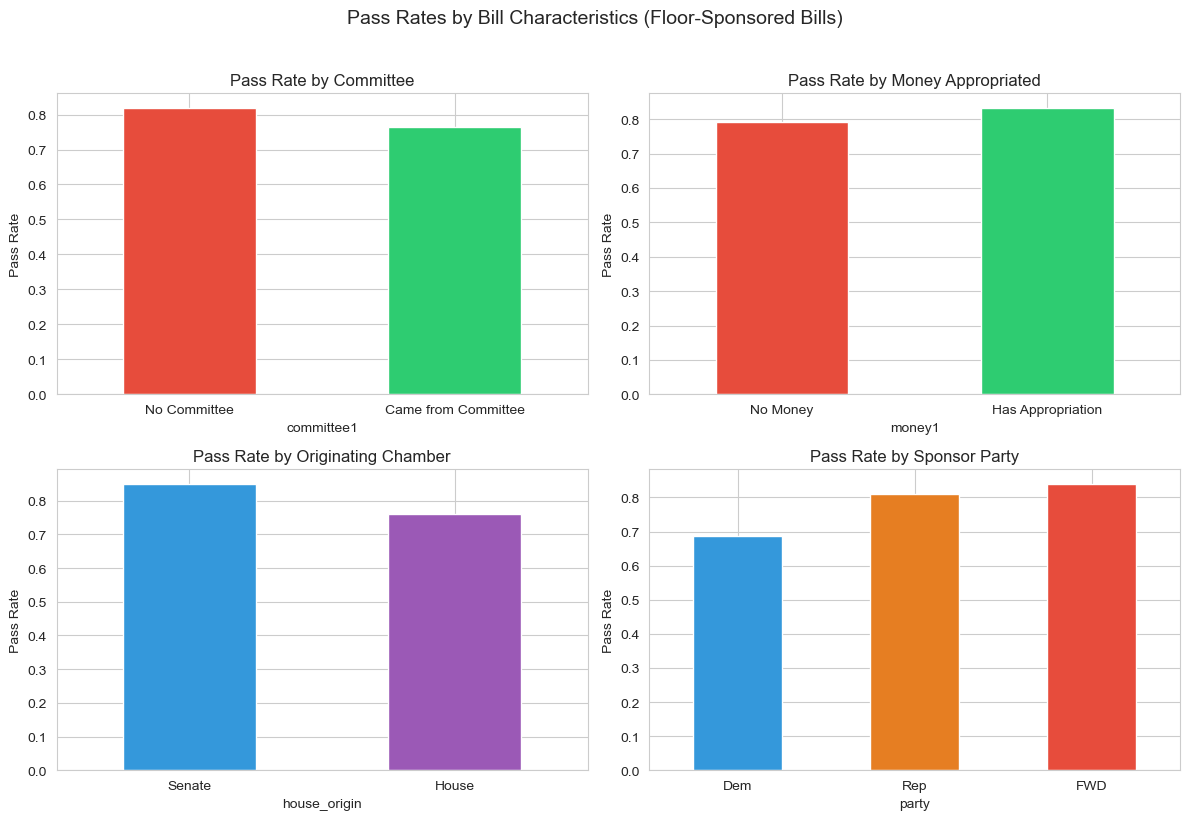

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Committee
ax = axes[0, 0]
df.groupby('committee1')['passed'].mean().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Pass Rate by Committee')
ax.set_xticklabels(['No Committee', 'Came from Committee'], rotation=0)
ax.set_ylabel('Pass Rate')

# Money appropriated
ax = axes[0, 1]
df.groupby('money1')['passed'].mean().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Pass Rate by Money Appropriated')
ax.set_xticklabels(['No Money', 'Has Appropriation'], rotation=0)
ax.set_ylabel('Pass Rate')

# Originating chamber
ax = axes[1, 0]
df.groupby('house_origin')['passed'].mean().plot(kind='bar', ax=ax, color=['#3498db', '#9b59b6'])
ax.set_title('Pass Rate by Originating Chamber')
ax.set_xticklabels(['Senate', 'House'], rotation=0)
ax.set_ylabel('Pass Rate')

# Sponsor party
ax = axes[1, 1]
party_pass = df.groupby('party')['passed'].mean().sort_values()
party_pass.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22', '#e74c3c'])
ax.set_title('Pass Rate by Sponsor Party')
ax.set_ylabel('Pass Rate')
ax.set_xticklabels(party_pass.index, rotation=0)

plt.suptitle('Pass Rates by Bill Characteristics (Floor-Sponsored Bills)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Pass Rates by Subject Area × Party

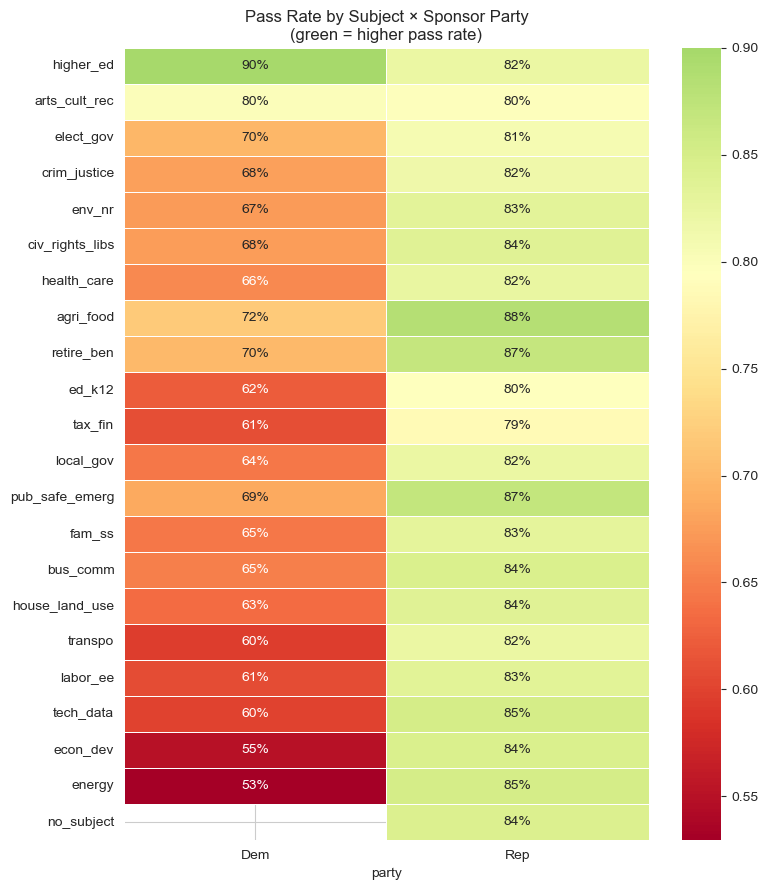

Largest Republican advantage (Rep pass rate - Dem pass rate):
subject
energy       0.319961
econ_dev     0.295953
tech_data    0.252018
labor_ee     0.226845
transpo      0.226642

Largest Democrat advantage:
subject
higher_ed       -0.078832
arts_cult_rec   -0.001613
elect_gov        0.108965
crim_justice     0.137434
env_nr           0.158204


In [6]:
subject_party = []
for col in SUBJECT_COLS:
    for party in ['Rep', 'Dem']:
        subset = df[(df[col] == 1) & (df['party'] == party)]
        if len(subset) > 5:
            subject_party.append({'subject': col, 'party': party,
                                  'pass_rate': subset['passed'].mean(), 'n': len(subset)})

sp_df = pd.DataFrame(subject_party)
sp_pivot = sp_df.pivot(index='subject', columns='party', values='pass_rate')
sp_pivot['gap'] = sp_pivot['Rep'] - sp_pivot['Dem']
sp_pivot = sp_pivot.sort_values('gap')

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(sp_pivot[['Dem', 'Rep']], annot=True, fmt='.0%', cmap='RdYlGn',
            center=df['passed'].mean(), linewidths=0.5, ax=ax)
ax.set_title('Pass Rate by Subject × Sponsor Party\n(green = higher pass rate)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("Largest Republican advantage (Rep pass rate - Dem pass rate):")
print(sp_pivot['gap'].sort_values(ascending=False).head(5).to_string())
print("\nLargest Democrat advantage:")
print(sp_pivot['gap'].sort_values().head(5).to_string())

### 1.5 Pass Rates Over Time & Economic Indicators

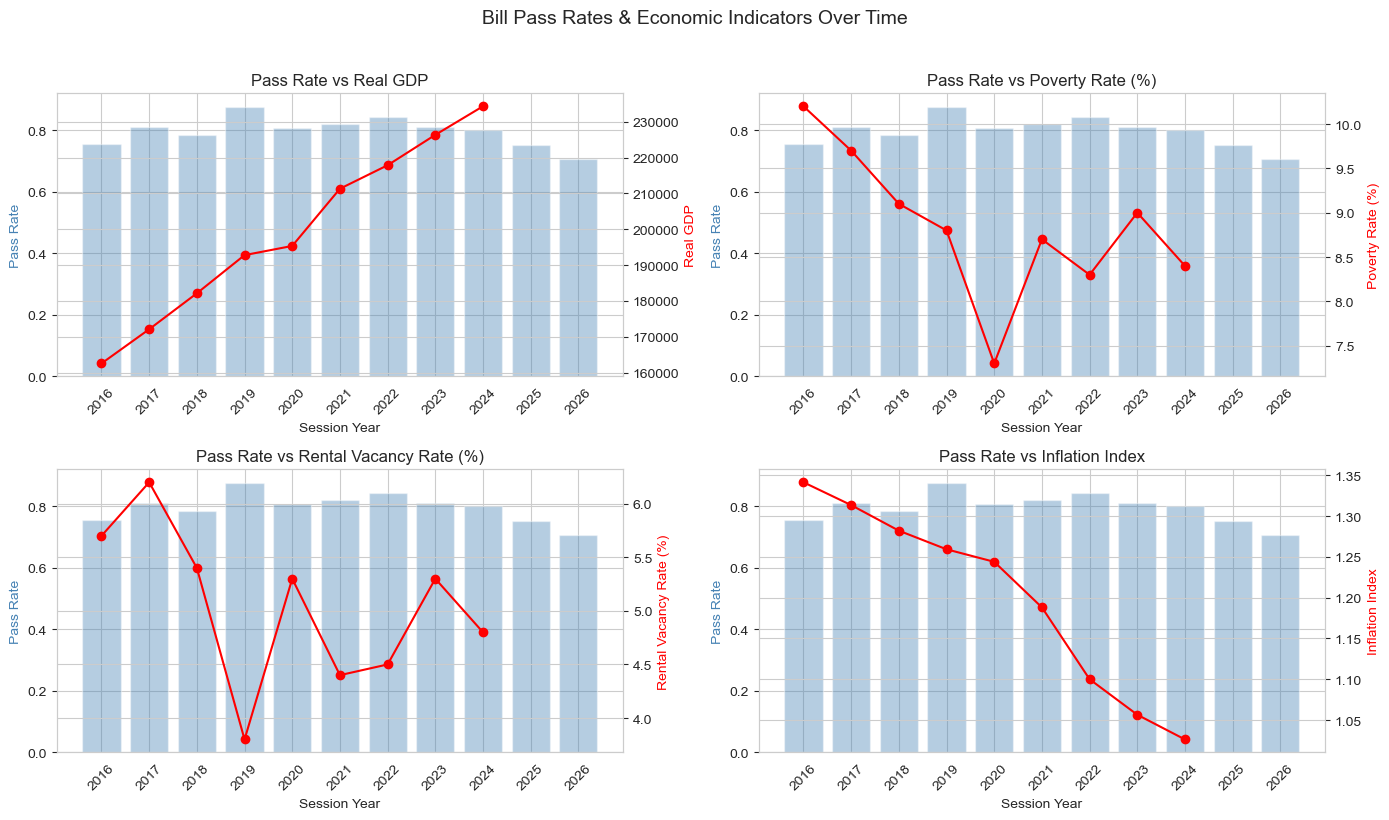

In [7]:
yearly = df.groupby('session_year').agg(
    pass_rate=('passed', 'mean'),
    n_bills=('passed', 'count'),
    real_gdp=('real_gdp', 'first'),
    poverty_rate=('poverty_rate', 'first'),
    rental_vacancy_rate=('rental_vacancy_rate', 'first'),
    inflation=('inflation', 'first')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, econ_var, label in zip(axes.flatten(),
    ['real_gdp', 'poverty_rate', 'rental_vacancy_rate', 'inflation'],
    ['Real GDP', 'Poverty Rate (%)', 'Rental Vacancy Rate (%)', 'Inflation Index']):

    ax2 = ax.twinx()
    ax.bar(yearly['session_year'], yearly['pass_rate'], alpha=0.4, color='steelblue', label='Pass Rate')
    ax2.plot(yearly['session_year'], yearly[econ_var], 'ro-', label=label)
    ax.set_xlabel('Session Year')
    ax.set_ylabel('Pass Rate', color='steelblue')
    ax2.set_ylabel(label, color='red')
    ax.set_title(f'Pass Rate vs {label}')
    ax.set_xticks(yearly['session_year'])
    ax.set_xticklabels(yearly['session_year'], rotation=45)

plt.suptitle('Bill Pass Rates & Economic Indicators Over Time', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.6 Correlation Matrix — Numeric Covariates

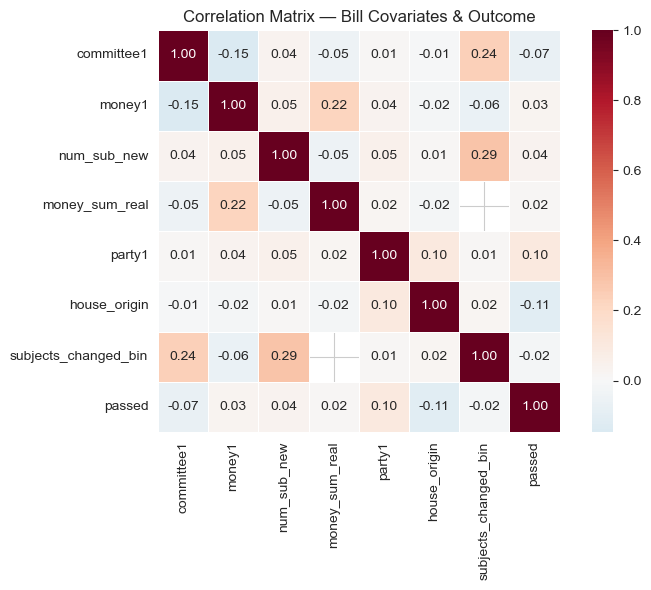

In [8]:
corr_cols = BILL_COVARIATES + ['house_origin', 'subjects_changed_bin', 'passed']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Bill Covariates & Outcome')
plt.tight_layout()
plt.show()

## 2. Predictive Modeling — Logistic Regression

We build three logistic regression models incrementally:

1. **Model 1 — Bill characteristics only**: subject dummies + bill covariates (chamber, committee, substitutes, money, **sponsor party**)
2. **Model 2 — Bill + ACS economic indicators**: adds real GDP, poverty rate, rental vacancy rate, inflation
3. **Model 3 — Bill + ACS + interactions**: adds interaction terms between economic indicators and key subject areas, plus **party × economic indicator** interactions

5-fold stratified CV; compare accuracy, F1, and ROC-AUC.

**Note:** ACS data is missing for 2024–2026, so Models 2 and 3 are restricted to 2016–2023 sessions. Model 1 is fit on the same subset for fair comparison.

In [9]:
# ── Prepare feature matrices ──

# Base feature columns (includes party1)
X_full_cols = SUBJECT_COLS + BILL_COVARIATES + ['house_origin', 'subjects_changed_bin']
y_full = df['passed'].copy()

# Subset with ACS data (for Models 1-3 comparison)
df_econ = df.dropna(subset=ECON_VARS).copy()
print(f"Analysis sample (floor-sponsored): {len(df)} bills")
print(f"With ACS data (2016-2023): {len(df_econ)} bills")
print(f"Pass rate in ACS subset: {df_econ['passed'].mean():.1%}")

y_econ = df_econ['passed'].copy()

# Model 1 features (bill only, includes party1)
X1 = df_econ[X_full_cols].copy()

# Model 2 features (bill + ACS)
X2_cols = X_full_cols + ECON_VARS
X2 = df_econ[X2_cols].copy()

# Model 3 features (bill + ACS + interactions)
interaction_subjects = ['health_care', 'fam_ss', 'ed_k12', 'crim_justice', 'tax_fin']
X3 = X2.copy()
for econ in ECON_VARS:
    for subj in interaction_subjects:
        X3[f'{econ}_x_{subj}'] = X3[econ] * X3[subj]
# Party × economic interactions
for econ in ECON_VARS:
    X3[f'{econ}_x_party1'] = X3[econ] * X3['party1']

print(f"\nFeature counts: Model 1={X1.shape[1]}, Model 2={X2.shape[1]}, Model 3={X3.shape[1]}")

Analysis sample (floor-sponsored): 6730 bills
With ACS data (2016-2023): 5312 bills
Pass rate in ACS subset: 81.2%

Feature counts: Model 1=29, Model 2=33, Model 3=57


In [10]:
# ── Cross-validated model comparison ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

results = {}
models_dict = {'Model 1: Bill Only': X1, 'Model 2: Bill + ACS': X2, 'Model 3: Bill + ACS + Interactions': X3}

for name, X in models_dict.items():
    X_scaled = scaler.fit_transform(X)
    lr = LogisticRegression(max_iter=1000, random_state=42)

    acc = cross_val_score(lr, X_scaled, y_econ, cv=cv, scoring='accuracy')
    f1 = cross_val_score(lr, X_scaled, y_econ, cv=cv, scoring='f1')
    auc = cross_val_score(lr, X_scaled, y_econ, cv=cv, scoring='roc_auc')

    results[name] = {
        'Accuracy': f'{acc.mean():.3f} ± {acc.std():.3f}',
        'F1 Score': f'{f1.mean():.3f} ± {f1.std():.3f}',
        'ROC-AUC': f'{auc.mean():.3f} ± {auc.std():.3f}',
        'acc_mean': acc.mean(), 'f1_mean': f1.mean(), 'auc_mean': auc.mean()
    }

results_df = pd.DataFrame(results).T[['Accuracy', 'F1 Score', 'ROC-AUC']]
print("5-Fold Stratified Cross-Validation Results")
print("=" * 60)
print(results_df.to_string())

5-Fold Stratified Cross-Validation Results
                                         Accuracy       F1 Score        ROC-AUC
Model 1: Bill Only                  0.812 ± 0.000  0.896 ± 0.000  0.606 ± 0.027
Model 2: Bill + ACS                 0.812 ± 0.000  0.896 ± 0.000  0.609 ± 0.027
Model 3: Bill + ACS + Interactions  0.812 ± 0.001  0.896 ± 0.001  0.618 ± 0.018


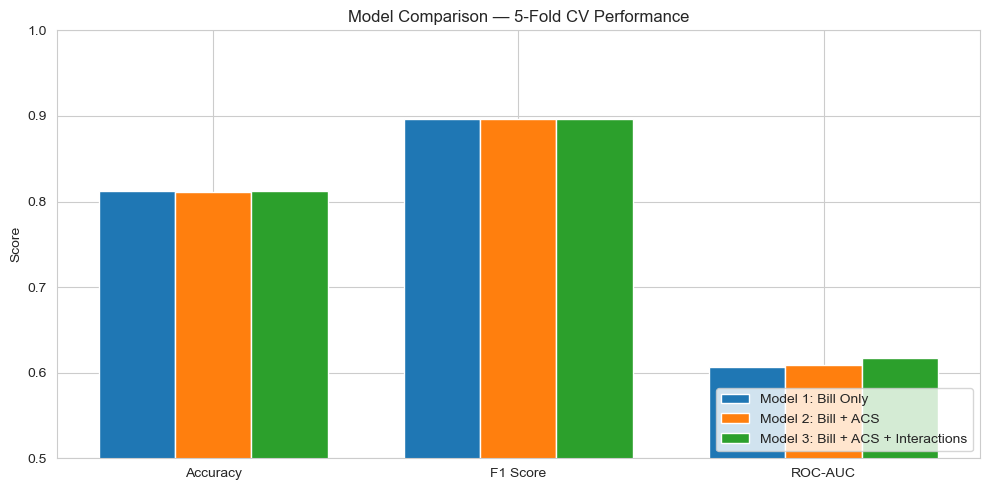

In [11]:
# ── Visualize model comparison ──
metrics = ['acc_mean', 'f1_mean', 'auc_mean']
labels = ['Accuracy', 'F1 Score', 'ROC-AUC']
model_names = list(results.keys())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
width = 0.25

for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name)

ax.set_ylabel('Score')
ax.set_title('Model Comparison — 5-Fold CV Performance')
ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

### 2.1 Logistic Regression Coefficients (Best Model)

Best model by AUC: Model 3: Bill + ACS + Interactions


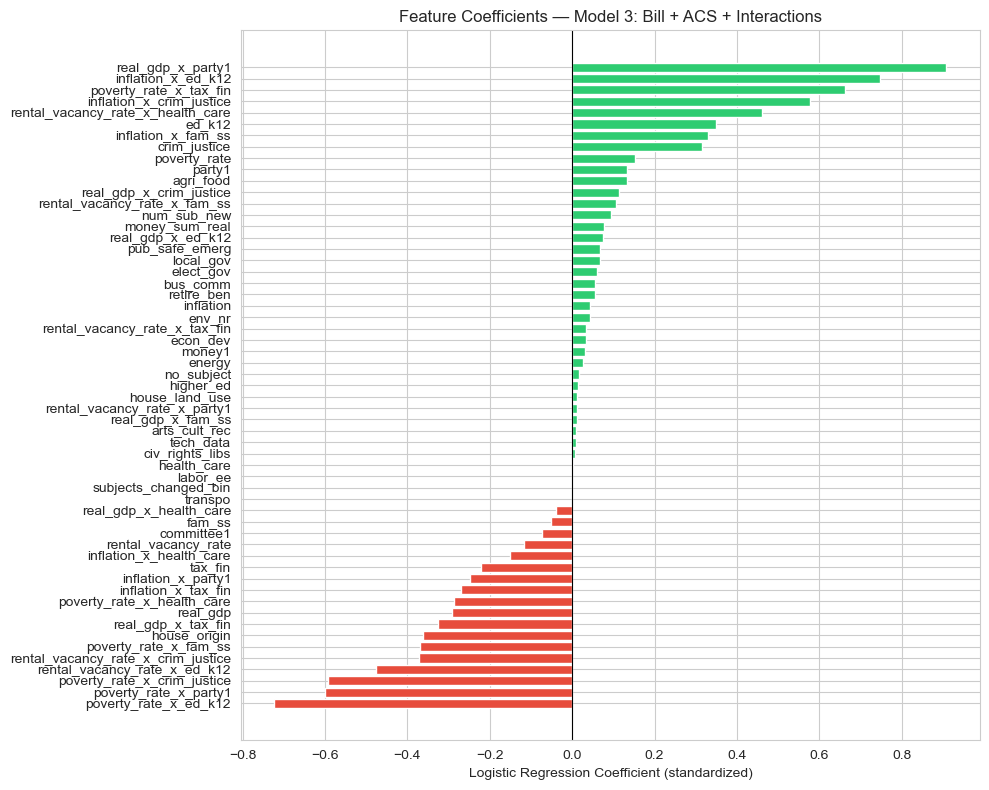


Top 10 positive predictors of passage:
                          Feature  Coefficient  Odds Ratio
                           party1     0.132607    1.141801
                     poverty_rate     0.152903    1.165212
                     crim_justice     0.315641    1.371138
               inflation_x_fam_ss     0.328974    1.389542
                           ed_k12     0.349503    1.418362
rental_vacancy_rate_x_health_care     0.459910    1.583932
         inflation_x_crim_justice     0.577723    1.781976
           poverty_rate_x_tax_fin     0.662798    1.940213
               inflation_x_ed_k12     0.746373    2.109336
                real_gdp_x_party1     0.908492    2.480579

Top 10 negative predictors of passage:
                           Feature  Coefficient  Odds Ratio
             poverty_rate_x_ed_k12    -0.722633    0.485472
             poverty_rate_x_party1    -0.599183    0.549260
       poverty_rate_x_crim_justice    -0.591433    0.553533
      rental_vacancy_rate_x_ed_

In [12]:
best_name = max(results, key=lambda k: results[k]['auc_mean'])
best_X = models_dict[best_name]
print(f"Best model by AUC: {best_name}")

X_scaled = scaler.fit_transform(best_X)
lr_best = LogisticRegression(max_iter=1000, random_state=42)
lr_best.fit(X_scaled, y_econ)

coef_df = pd.DataFrame({
    'Feature': best_X.columns,
    'Coefficient': lr_best.coef_[0],
    'Odds Ratio': np.exp(lr_best.coef_[0])
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (standardized)')
ax.set_title(f'Feature Coefficients — {best_name}')
plt.tight_layout()
plt.show()

print("\nTop 10 positive predictors of passage:")
print(coef_df.tail(10)[['Feature', 'Coefficient', 'Odds Ratio']].to_string(index=False))
print("\nTop 10 negative predictors of passage:")
print(coef_df.head(10)[['Feature', 'Coefficient', 'Odds Ratio']].to_string(index=False))

### 2.2 ROC Curve

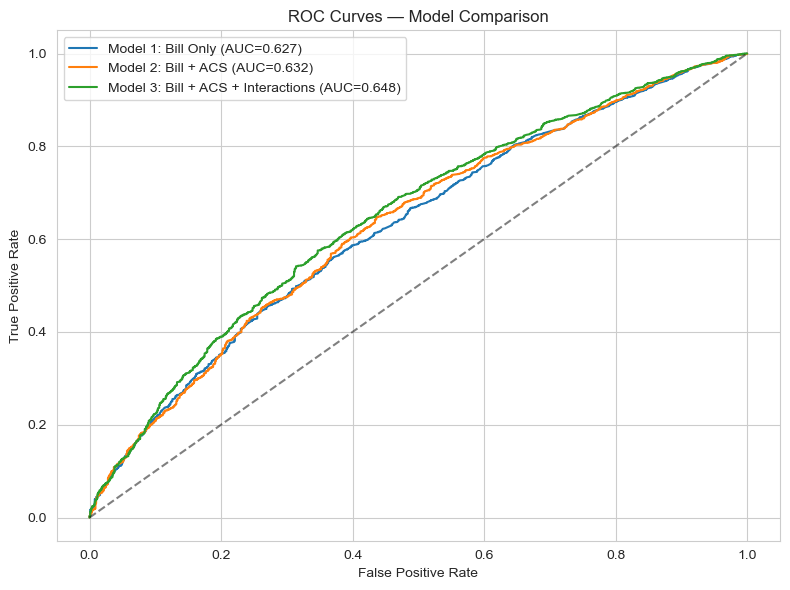

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, X in models_dict.items():
    X_scaled = scaler.fit_transform(X)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_scaled, y_econ)
    y_prob = lr.predict_proba(X_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_econ, y_prob)
    auc_val = roc_auc_score(y_econ, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Classification Trees & Feature Importance

Decision trees serve as the interpretable, constituent-facing output. We fit:
1. A single decision tree (pruned for readability) to visualize the decision rules
2. A random forest to get stable feature importance rankings

Both use the full floor-sponsored sample (all years, no ACS restriction) and include `party1`.

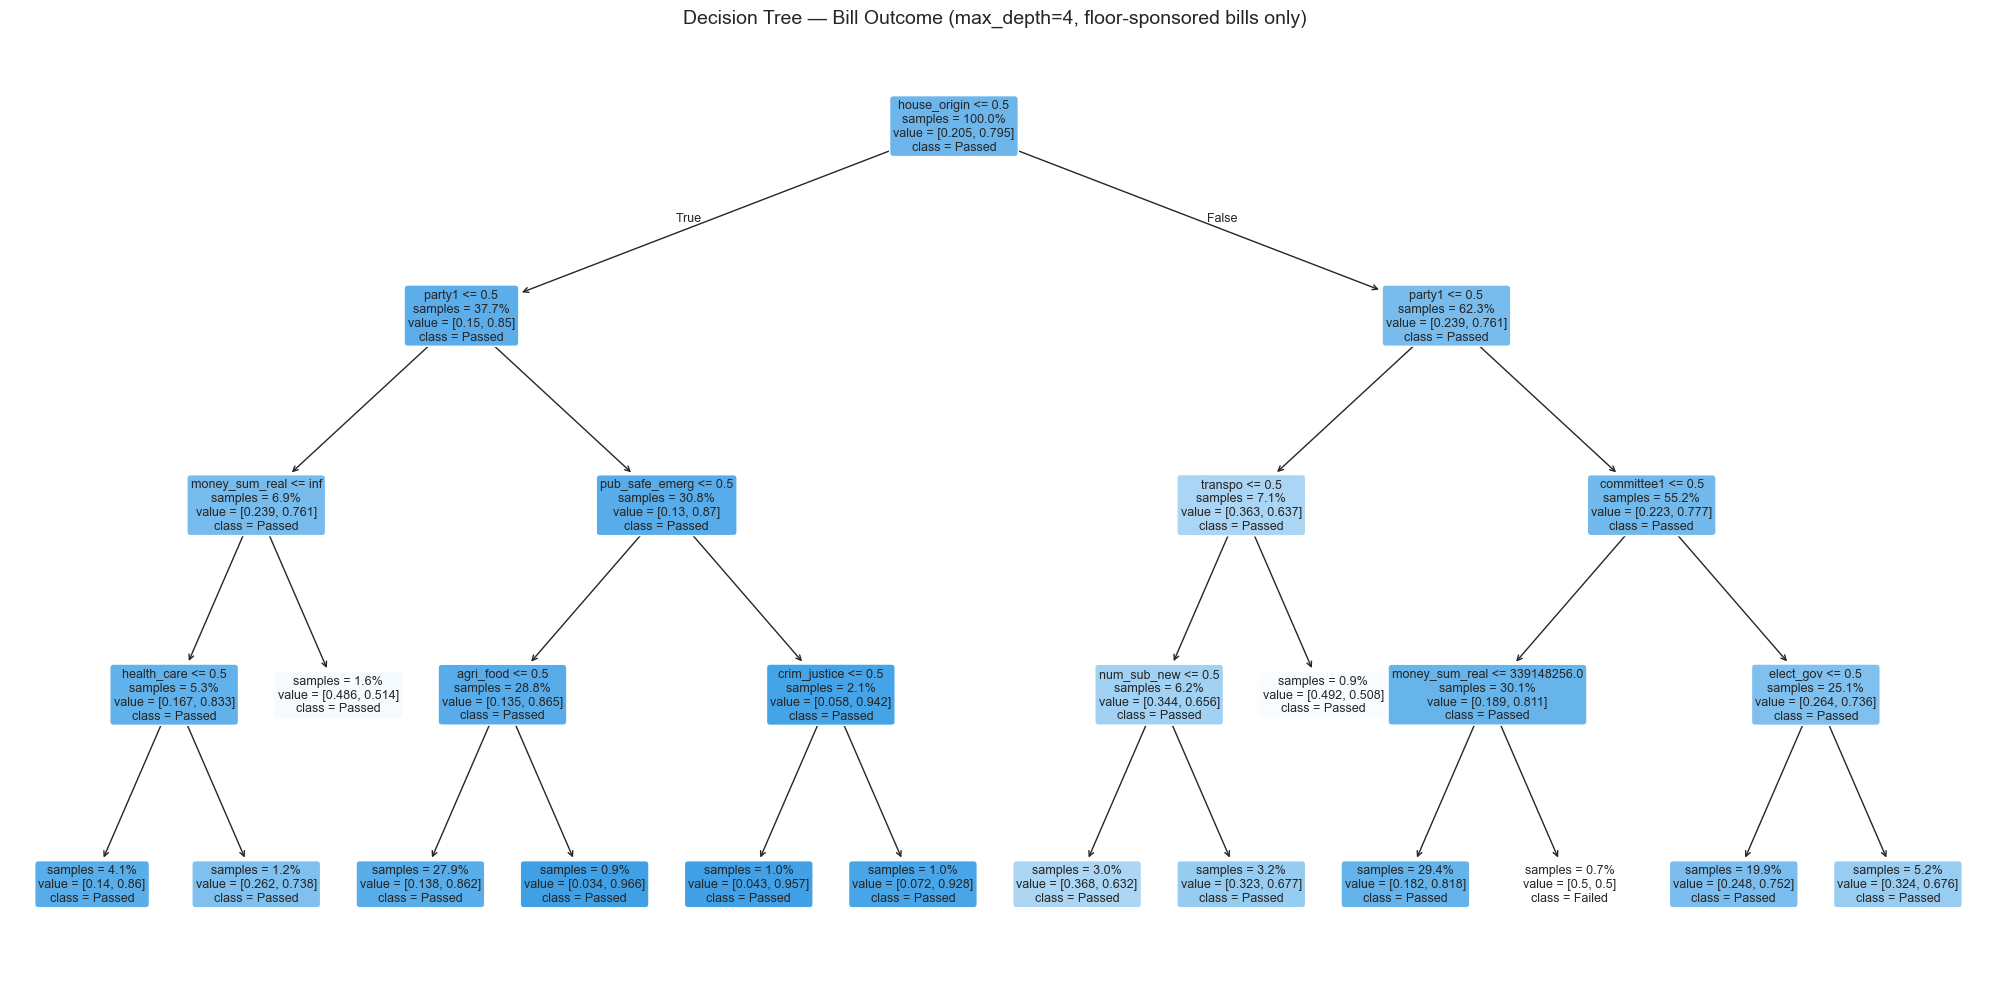

Decision Tree CV Accuracy: 0.682 ± 0.225


In [14]:
feature_cols = SUBJECT_COLS + BILL_COVARIATES + ['house_origin', 'subjects_changed_bin']

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)
dt.fit(df[feature_cols], y_full)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt, feature_names=feature_cols, class_names=['Failed', 'Passed'],
          filled=True, rounded=True, fontsize=9, ax=ax,
          proportion=True, impurity=False)
ax.set_title('Decision Tree — Bill Outcome (max_depth=4, floor-sponsored bills only)', fontsize=14)
plt.tight_layout()
plt.show()

dt_cv = cross_val_score(dt, df[feature_cols], y_full, cv=5, scoring='accuracy')
print(f"Decision Tree CV Accuracy: {dt_cv.mean():.3f} ± {dt_cv.std():.3f}")

### 3.1 Random Forest Feature Importance

Random Forest CV Accuracy: 0.715 ± 0.160


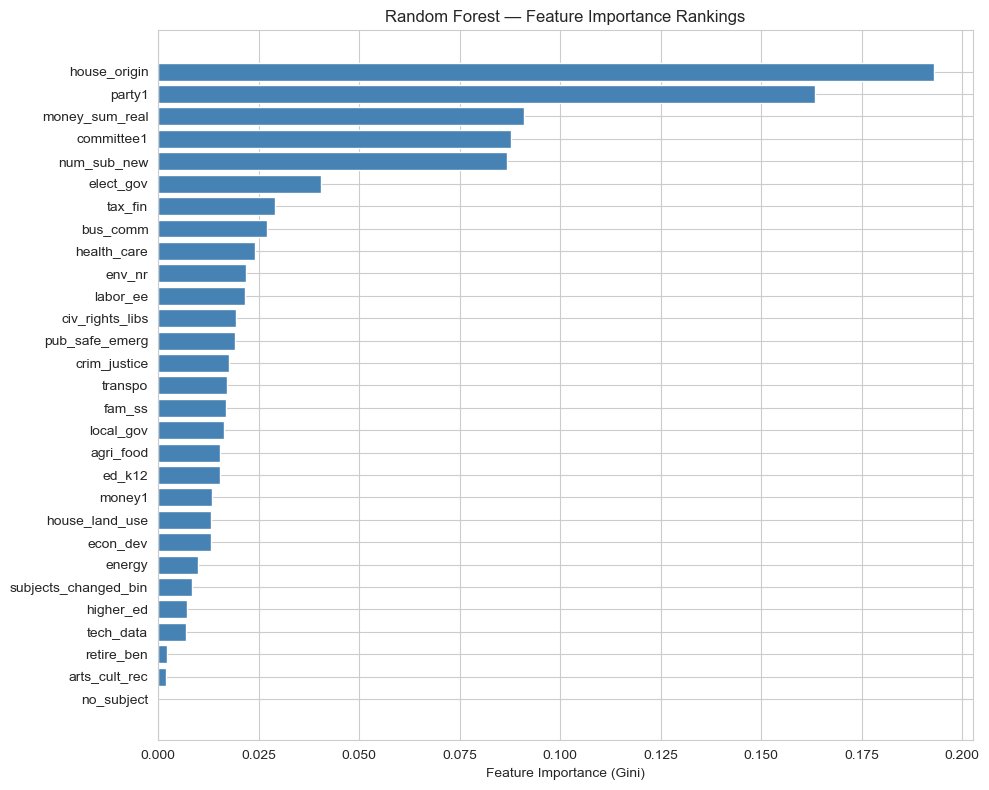


Top 10 most important features:
       Feature  Importance
        env_nr    0.021812
   health_care    0.024051
      bus_comm    0.027011
       tax_fin    0.029166
     elect_gov    0.040566
   num_sub_new    0.086829
    committee1    0.087785
money_sum_real    0.090972
        party1    0.163458
  house_origin    0.193028


In [15]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                            random_state=42, n_jobs=-1)
rf.fit(df[feature_cols], y_full)

rf_cv = cross_val_score(rf, df[feature_cols], y_full, cv=5, scoring='accuracy')
print(f"Random Forest CV Accuracy: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")

imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importance Rankings')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(imp_df.tail(10)[['Feature', 'Importance']].to_string(index=False))

## 4. Neural Network vs Random Forest

We compare the random forest against a Multi-Layer Perceptron (MLP) neural network to test whether the additional model complexity captures nonlinear patterns that the tree-based model misses.

Since neural network performance is sensitive to architecture, we first search across multiple configurations — varying the number of layers and neurons — to find the best MLP before comparing it to the random forest. All architectures use ReLU activation, early stopping, and are trained on standardized features with 5-fold stratified CV.

In [16]:
# ── MLP Architecture Search ──
# MLPClassifier can't handle NaNs — fill missing money_sum_real with 0
# (bills with no appropriation) before scaling
scaler_nn = StandardScaler()
X_nn = scaler_nn.fit_transform(df[feature_cols].fillna(0))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Architectures to test: from simple to complex
architectures = {
    '1 layer (32)':       (32,),
    '1 layer (64)':       (64,),
    '1 layer (128)':      (128,),
    '2 layers (64→32)':   (64, 32),
    '2 layers (128→64)':  (128, 64),
    '3 layers (128→64→32)': (128, 64, 32),
}

arch_results = {}
for name, layers in architectures.items():
    mlp = MLPClassifier(hidden_layer_sizes=layers, activation='relu',
                        max_iter=500, random_state=42, early_stopping=True,
                        validation_fraction=0.1)
    acc = cross_val_score(mlp, X_nn, y_full, cv=cv, scoring='accuracy')
    f1 = cross_val_score(mlp, X_nn, y_full, cv=cv, scoring='f1')
    auc = cross_val_score(mlp, X_nn, y_full, cv=cv, scoring='roc_auc')
    arch_results[name] = {
        'layers': layers,
        'Accuracy': f'{acc.mean():.3f} ± {acc.std():.3f}',
        'F1 Score': f'{f1.mean():.3f} ± {f1.std():.3f}',
        'ROC-AUC': f'{auc.mean():.3f} ± {auc.std():.3f}',
        'acc_mean': acc.mean(), 'f1_mean': f1.mean(), 'auc_mean': auc.mean()
    }
    print(f'{name:25s}  Acc={acc.mean():.3f}  F1={f1.mean():.3f}  AUC={auc.mean():.3f}')

arch_df = pd.DataFrame(arch_results).T[['Accuracy', 'F1 Score', 'ROC-AUC']]
print('\nMLP Architecture Search — 5-Fold Stratified CV')
print('=' * 65)
print(arch_df.to_string())

1 layer (32)               Acc=0.792  F1=0.883  AUC=0.572
1 layer (64)               Acc=0.792  F1=0.884  AUC=0.560
1 layer (128)              Acc=0.794  F1=0.885  AUC=0.594
2 layers (64→32)           Acc=0.792  F1=0.883  AUC=0.596
2 layers (128→64)          Acc=0.794  F1=0.885  AUC=0.600
3 layers (128→64→32)       Acc=0.792  F1=0.883  AUC=0.599

MLP Architecture Search — 5-Fold Stratified CV
                           Accuracy       F1 Score        ROC-AUC
1 layer (32)          0.792 ± 0.002  0.883 ± 0.002  0.572 ± 0.014
1 layer (64)          0.792 ± 0.002  0.884 ± 0.001  0.560 ± 0.017
1 layer (128)         0.794 ± 0.001  0.885 ± 0.001  0.594 ± 0.025
2 layers (64→32)      0.792 ± 0.003  0.883 ± 0.002  0.596 ± 0.057
2 layers (128→64)     0.794 ± 0.000  0.885 ± 0.000  0.600 ± 0.038
3 layers (128→64→32)  0.792 ± 0.005  0.883 ± 0.003  0.599 ± 0.020


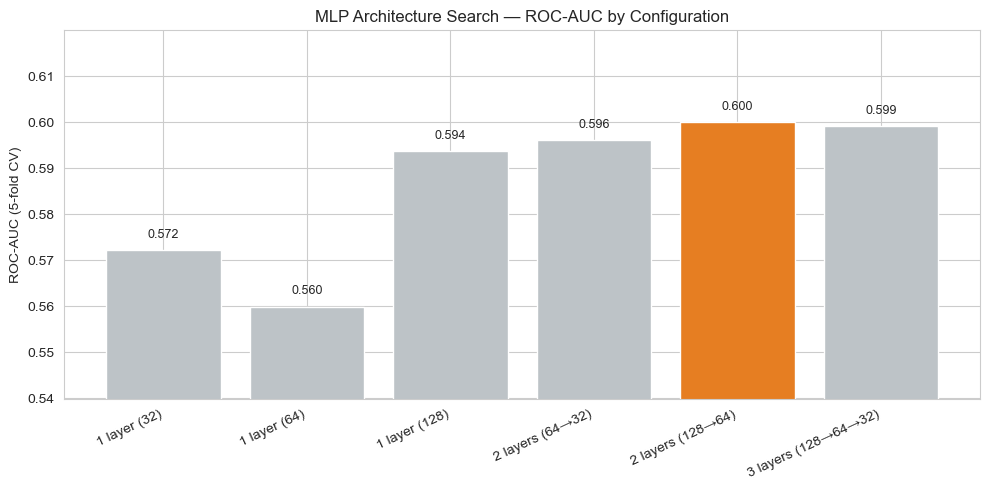


Best architecture: 2 layers (128→64) (layers=(128, 64))


In [17]:
# ── Visualize architecture search ──
fig, ax = plt.subplots(figsize=(10, 5))

arch_names = list(arch_results.keys())
auc_vals = [arch_results[n]['auc_mean'] for n in arch_names]
colors = ['#e67e22' if v == max(auc_vals) else '#bdc3c7' for v in auc_vals]

bars = ax.bar(arch_names, auc_vals, color=colors, edgecolor='white')
for bar, val in zip(bars, auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2., val + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('MLP Architecture Search — ROC-AUC by Configuration')
ax.set_ylim(min(auc_vals) - 0.02, max(auc_vals) + 0.02)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

best_arch_name = max(arch_results, key=lambda k: arch_results[k]['auc_mean'])
best_arch_layers = arch_results[best_arch_name]['layers']
print(f'\nBest architecture: {best_arch_name} (layers={best_arch_layers})')

### 4.1 Best MLP vs Random Forest

Random Forest vs Best MLP (2 layers (128→64)) — 5-Fold Stratified CV
          Random Forest Best MLP 2 layers (128→64)
Accuracy  0.795 ± 0.000              0.794 ± 0.000
F1 Score  0.885 ± 0.000              0.885 ± 0.000
ROC-AUC   0.638 ± 0.019              0.600 ± 0.038


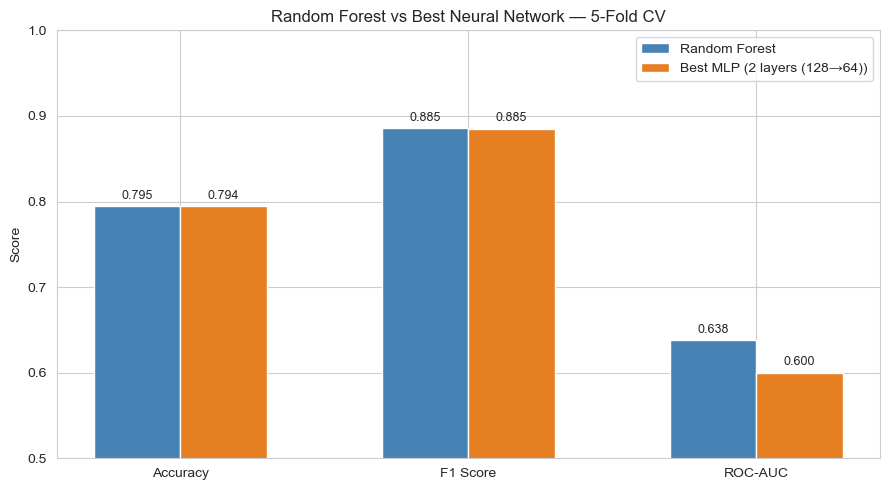

In [18]:
# ── Best MLP vs Random Forest: full comparison ──
best_mlp = MLPClassifier(hidden_layer_sizes=best_arch_layers, activation='relu',
                          max_iter=500, random_state=42, early_stopping=True,
                          validation_fraction=0.1)

# CV scores for both on the same folds
rf_acc = cross_val_score(rf, df[feature_cols], y_full, cv=cv, scoring='accuracy')
rf_f1 = cross_val_score(rf, df[feature_cols], y_full, cv=cv, scoring='f1')
rf_auc = cross_val_score(rf, df[feature_cols], y_full, cv=cv, scoring='roc_auc')

mlp_acc = cross_val_score(best_mlp, X_nn, y_full, cv=cv, scoring='accuracy')
mlp_f1 = cross_val_score(best_mlp, X_nn, y_full, cv=cv, scoring='f1')
mlp_auc = cross_val_score(best_mlp, X_nn, y_full, cv=cv, scoring='roc_auc')

comp = pd.DataFrame({
    'Random Forest': {
        'Accuracy': f'{rf_acc.mean():.3f} ± {rf_acc.std():.3f}',
        'F1 Score': f'{rf_f1.mean():.3f} ± {rf_f1.std():.3f}',
        'ROC-AUC': f'{rf_auc.mean():.3f} ± {rf_auc.std():.3f}'
    },
    f'Best MLP {best_arch_name}': {
        'Accuracy': f'{mlp_acc.mean():.3f} ± {mlp_acc.std():.3f}',
        'F1 Score': f'{mlp_f1.mean():.3f} ± {mlp_f1.std():.3f}',
        'ROC-AUC': f'{mlp_auc.mean():.3f} ± {mlp_auc.std():.3f}'
    }
})

print(f'Random Forest vs Best MLP ({best_arch_name}) — 5-Fold Stratified CV')
print('=' * 65)
print(comp.to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 5))
metrics_labels = ['Accuracy', 'F1 Score', 'ROC-AUC']
rf_vals = [rf_acc.mean(), rf_f1.mean(), rf_auc.mean()]
mlp_vals = [mlp_acc.mean(), mlp_f1.mean(), mlp_auc.mean()]
x = np.arange(len(metrics_labels))
width = 0.3
bars1 = ax.bar(x - width/2, rf_vals, width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, mlp_vals, width, label=f'Best MLP ({best_arch_name})', color='#e67e22')
ax.set_ylabel('Score')
ax.set_title('Random Forest vs Best Neural Network — 5-Fold CV')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0.5, 1.0)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 Confusion Matrices — Side by Side

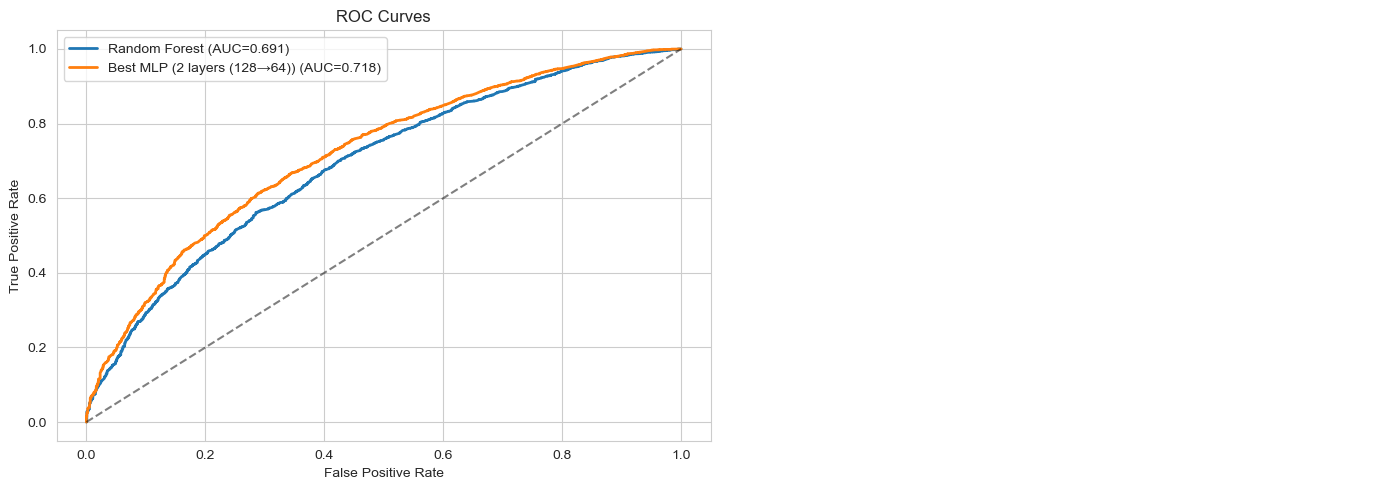

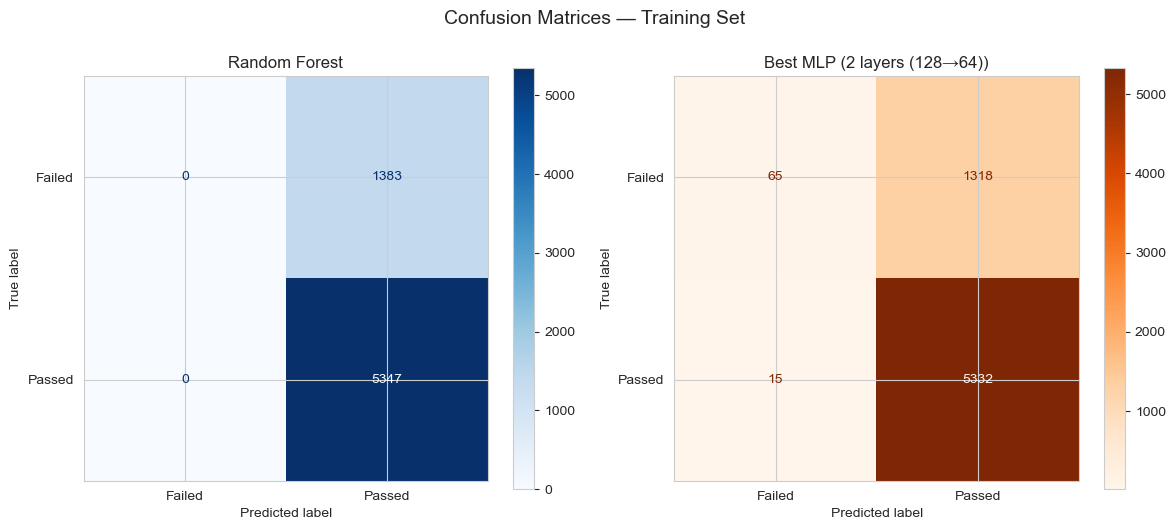

Random Forest:
              precision    recall  f1-score   support

      Failed       0.00      0.00      0.00      1383
      Passed       0.79      1.00      0.89      5347

    accuracy                           0.79      6730
   macro avg       0.40      0.50      0.44      6730
weighted avg       0.63      0.79      0.70      6730


Neural Network — Best MLP (2 layers (128→64)):
              precision    recall  f1-score   support

      Failed       0.81      0.05      0.09      1383
      Passed       0.80      1.00      0.89      5347

    accuracy                           0.80      6730
   macro avg       0.81      0.52      0.49      6730
weighted avg       0.80      0.80      0.72      6730



In [19]:
# Fit both on full data for confusion matrices and ROC
rf_full = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                                  random_state=42, n_jobs=-1)
rf_full.fit(df[feature_cols], y_full)
rf_probs = rf_full.predict_proba(df[feature_cols])[:, 1]
rf_pred = rf_full.predict(df[feature_cols])

mlp_full = MLPClassifier(hidden_layer_sizes=best_arch_layers, activation='relu',
                          max_iter=500, random_state=42, early_stopping=True,
                          validation_fraction=0.1)
mlp_full.fit(X_nn, y_full)
mlp_probs = mlp_full.predict_proba(X_nn)[:, 1]
mlp_pred = mlp_full.predict(X_nn)

# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, probs in [('Random Forest', rf_probs), (f'Best MLP ({best_arch_name})', mlp_probs)]:
    fpr, tpr, _ = roc_curve(y_full, probs)
    auc_val = roc_auc_score(y_full, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()

# Confusion matrices side by side
ax = axes[1]
ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_full, rf_pred,
                                         display_labels=['Failed', 'Passed'],
                                         cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest')

ConfusionMatrixDisplay.from_predictions(y_full, mlp_pred,
                                         display_labels=['Failed', 'Passed'],
                                         cmap='Oranges', ax=axes[1])
axes[1].set_title(f'Best MLP ({best_arch_name})')
plt.suptitle('Confusion Matrices — Training Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Random Forest:')
print(classification_report(y_full, rf_pred, target_names=['Failed', 'Passed']))
print(f'\nNeural Network — Best MLP ({best_arch_name}):')
print(classification_report(y_full, mlp_pred, target_names=['Failed', 'Passed']))

## 5. Bonus — Location Stage as Ordinal Outcome

`location_stage` (0–3) captures *how far* a bill got, not just pass/fail. Even among floor-sponsored bills, some die at stage 0, providing useful variation.

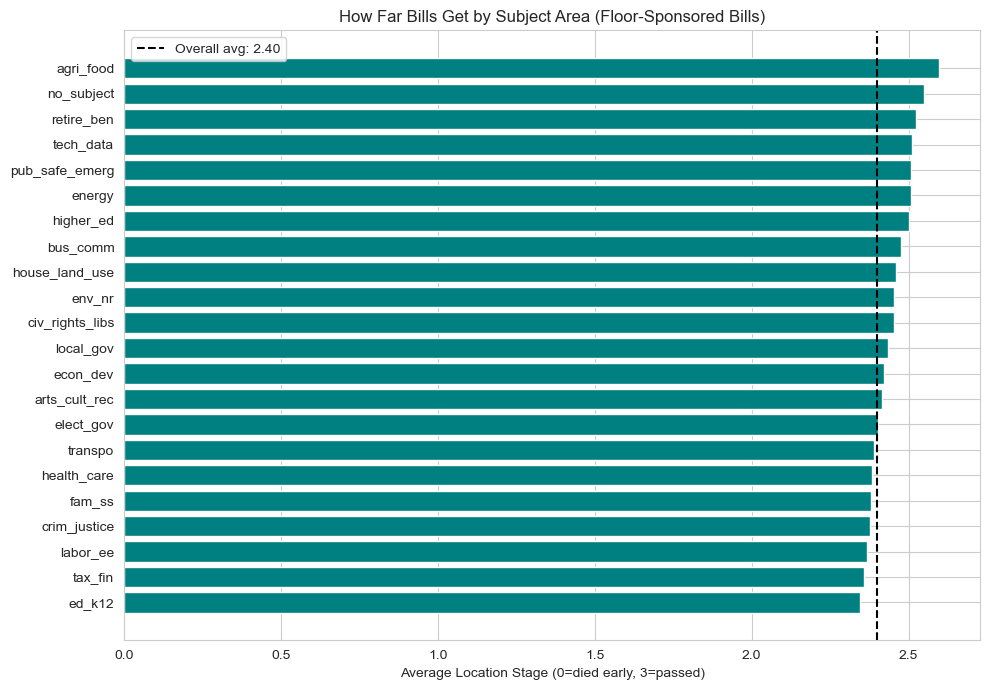

In [20]:
stage_by_subj = {}
for col in SUBJECT_COLS:
    subset = df[df[col] == 1]
    if len(subset) > 10:
        stage_by_subj[col] = subset['location_stage'].mean()

stage_df = pd.Series(stage_by_subj).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(stage_df.index, stage_df.values, color='teal', edgecolor='white')
ax.axvline(df['location_stage'].mean(), color='black', linestyle='--',
           label=f'Overall avg: {df["location_stage"].mean():.2f}')
ax.set_xlabel('Average Location Stage (0=died early, 3=passed)')
ax.set_title('How Far Bills Get by Subject Area (Floor-Sponsored Bills)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.1 Location Stage by Party

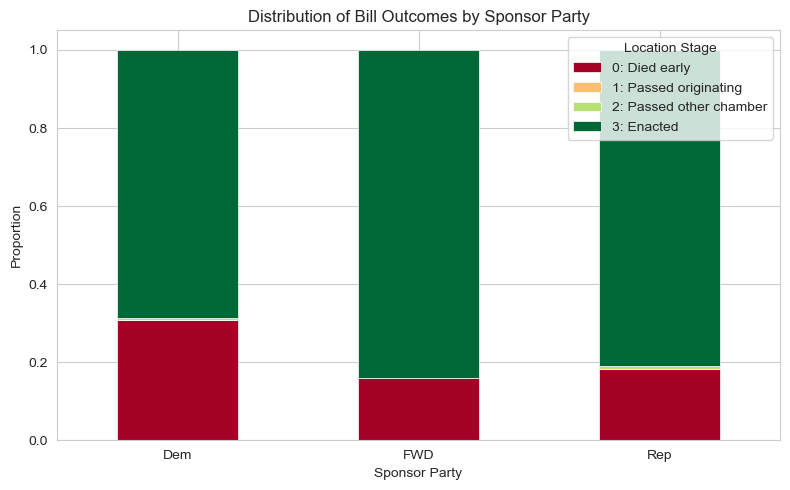

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
stage_party = df.groupby('party')['location_stage'].value_counts(normalize=True).unstack(fill_value=0)
stage_party.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn',
                 edgecolor='white', linewidth=0.5)
ax.set_title('Distribution of Bill Outcomes by Sponsor Party')
ax.set_xlabel('Sponsor Party')
ax.set_ylabel('Proportion')
ax.legend(title='Location Stage', labels=['0: Died early', '1: Passed originating', '2: Passed other chamber', '3: Enacted'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 6. Summary & Next Steps

### Sample Selection
We restricted the analysis to the 6,730 bills (77.3% of the full dataset) that had a floor sponsor. Bills without a floor sponsor cannot pass, so including them would let models trivially predict failure based on a procedural gatekeeper rather than substantive bill characteristics.

### Key Findings
- **Sponsor party**: `party1` (Republican = 1) is included in all models. The EDA shows a meaningful gap in pass rates between Republican- and Democrat-sponsored bills. The subject × party heatmap reveals which policy areas show the largest partisan gaps.
- **Logistic regression comparison**: The CV table shows whether adding ACS economic indicators and interaction terms improved predictive power.
- **Feature importance**: The random forest ranking shows where `party1` lands relative to subject areas and other bill characteristics.
- **Decision tree**: Reveals whether party affiliation appears as an early splitting variable.
- **Neural network vs random forest**: We tested six MLP architectures (from a single 32-neuron layer up to three layers with 128→64→32 neurons) and compared the best-performing configuration against the random forest. If performance is similar across architectures and close to the random forest, it suggests the relationships in this data are well-captured by simpler models — and the random forest's interpretability (via feature importance) makes it the better practical choice.

### Limitations & Future Work
- `party1` is binary (Rep vs. not-Rep), grouping Democrats and Forward Party together. With only 81 FWD bills, a three-way split may not have enough power, but it's worth exploring.
- Cosponsor data (`cospon1`, `cospon_num`) is only available from 2023 onward.
- ACS data is missing for 2024–2026.
- Bipartisan cosponsorship (cross-party floor sponsors) could be a powerful predictor if floor sponsor party were also available.
- The class imbalance is ~80/20 in this filtered sample; consider class weights if recall on failed bills is low.